<a href="https://colab.research.google.com/github/Lufsenna/3-fase---3-Desafio-Telecom-X-Parte-2-Previs-o-de-Churn-Machine-Learning-/blob/main/3%C2%AA_fase_3%C2%AA_Desafio_Telecom_X_%E2%80%93_Parte_2_Previs%C3%A3o_de_Churn_(Machine_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom X – Parte 2 Previsão de Churn (Machine Learning)**

# **1. Importar Bibliotecas**

In [139]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# **2. Carregar Dataset Tratado**

In [140]:
from google.colab import files
uploaded = files.upload()

Saving telecomx1parte_tratado_final.csv to telecomx1parte_tratado_final (3).csv


In [141]:
df = pd.read_csv('/content/telecomx1parte_tratado_final.csv')

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0.0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


# **3. Informações do Dataset**

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [143]:
df.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337
std,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


# **4. Remover Colunas Irrelevantes**

In [144]:
df = df.drop(columns=['customerID'], errors='ignore')

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0.0,0,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0.0,1,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1.0,1,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1.0,1,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1.0,0,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


# **5. Encoding (Transformar categorias em números)**

In [145]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,0,1,1,9,1,1,65.6,593.30,...,False,True,False,False,False,True,False,False,False,True
1,0.0,1,0,0,0,9,1,0,59.9,542.40,...,False,False,False,True,False,False,False,False,False,True
2,1.0,1,0,0,0,4,1,1,73.9,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,1,0,13,1,1,98.0,1237.85,...,False,True,False,True,False,False,False,False,True,False
4,1.0,0,1,1,0,3,1,1,83.9,267.40,...,False,True,False,False,False,False,False,False,False,True


# **6. Verificar Proporção de Churn**

In [146]:
df['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [147]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.463013
1.0,26.536987


6.1 - Gráfico

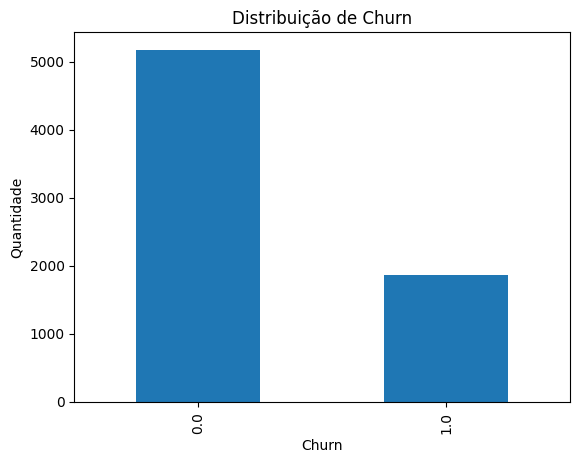

In [148]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade')

plt.show()

# **7. Análise de Correlação**

In [149]:
correlation_matrix = df_encoded.corr()

**7.1 - Heatmap**

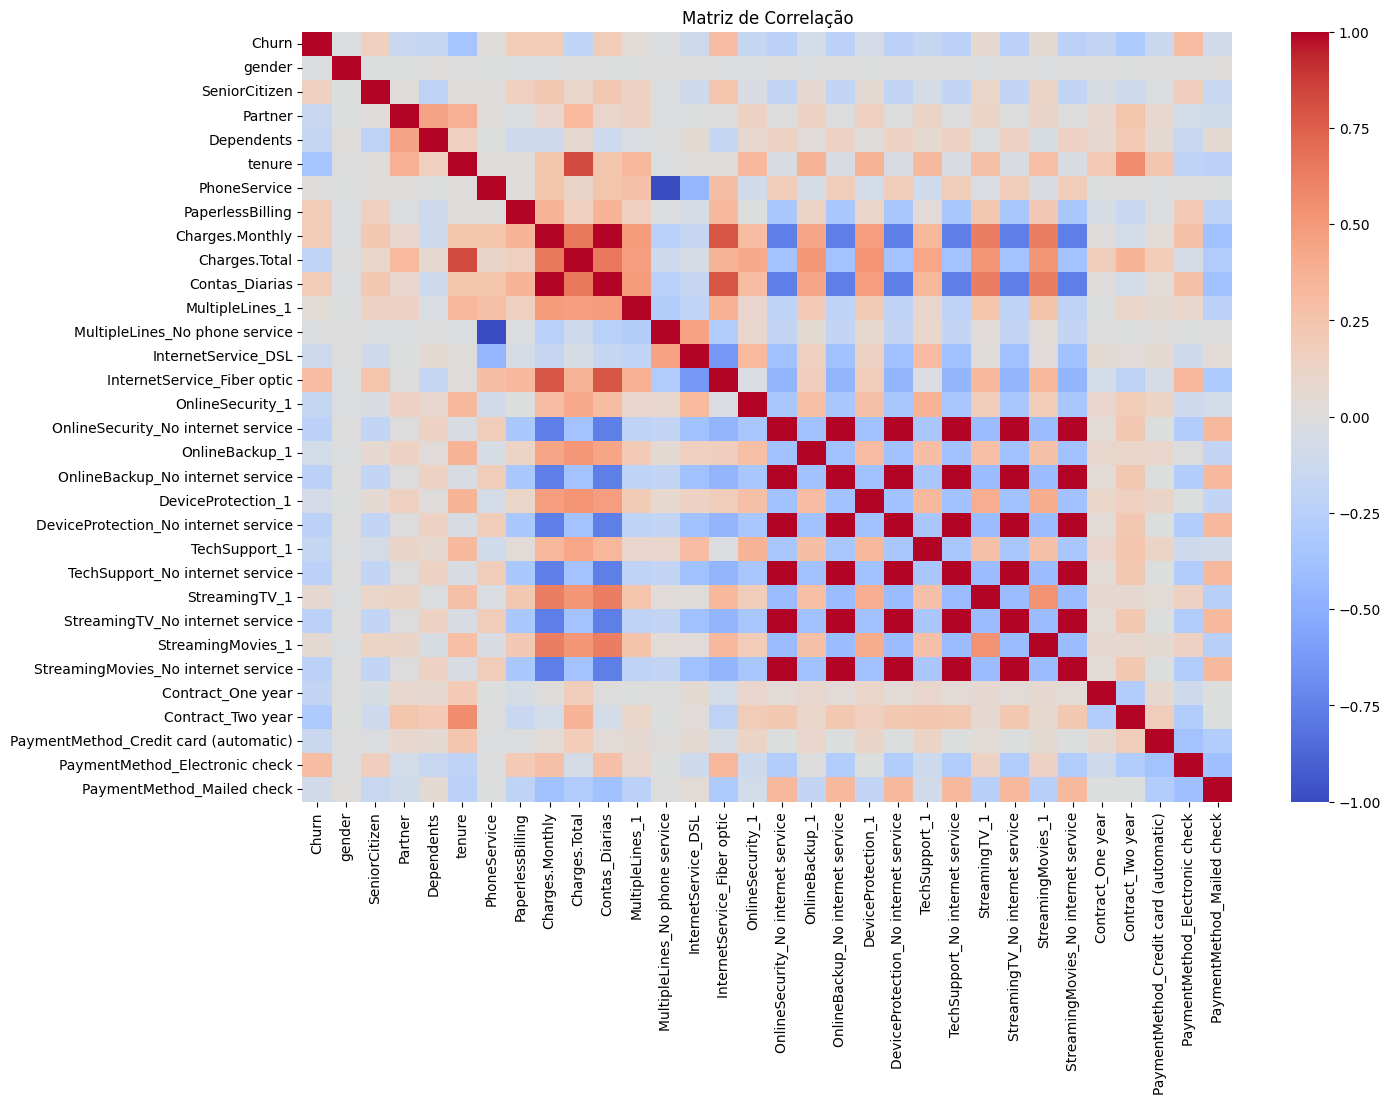

In [150]:
plt.figure(figsize=(15,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")

plt.show()

# **8. Variáveis mais relacionadas ao Churn**

In [151]:
corr_churn = correlation_matrix['Churn'].sort_values(ascending=False)

corr_churn.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Contas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_1,0.063228
StreamingMovies_1,0.061382
MultipleLines_1,0.040102


# **9. Análises Direcionadas**

**9.1 - Tempo de contrato × churn**

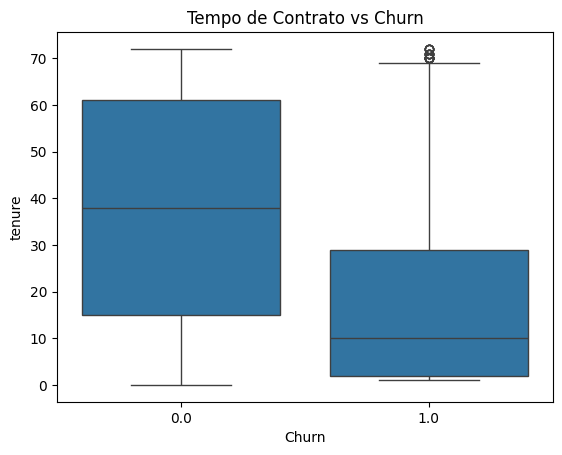

In [152]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tempo de Contrato vs Churn")

plt.show()

**9.2 - Total gasto × churn**

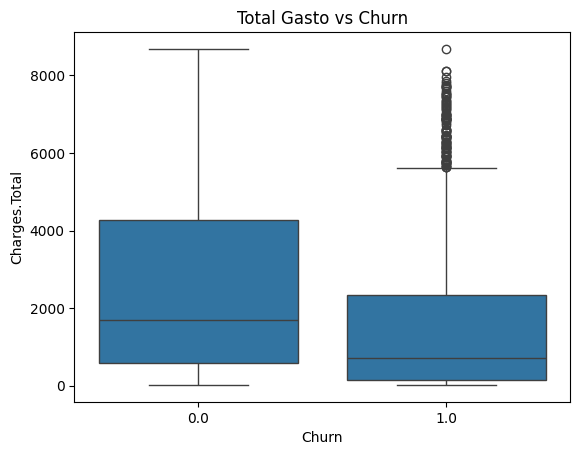

In [153]:
sns.boxplot(x='Churn', y='Charges.Total', data=df)

plt.title("Total Gasto vs Churn")

plt.show()

# **10. Separar Variáveis para Machine Learning**

In [154]:
y = df_encoded['Churn']
X = df_encoded.drop('Churn', axis=1)

# **11. Separação Treino e Teste**

In [155]:
valid_indices = y.dropna().index
X_cleaned = X.loc[valid_indices]
y_cleaned = y.loc[valid_indices]

X_cleaned = X_cleaned.dropna()
y_cleaned = y_cleaned.loc[X_cleaned.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.3,
    random_state=42,
    stratify=y_cleaned
)

# **12. Balanceamento com SMOTE**

In [156]:
!pip install imbalanced-learn

**12.2 - Aplicar SMOTE:**

In [157]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# **13. Normalização dos Dados**

In [158]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test)

# **14. Modelo 1 — Regressão Logística**

In [174]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_bal)

LogisticRegression(max_iter=1000)

**14.1 - Previsões**

In [160]:
y_pred_log = log_model.predict(X_test_scaled)

# **15. Modelo 2 — Random Forest**

In [173]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(random_state=42)

**15. 1 - Previsões**

In [162]:
y_pred_rf = rf_model.predict(X_test)

# **16. Avaliação — Regressão Logística**

**16.1 - Regressão Logística**

In [163]:
print('--- Avaliação do Modelo de Regressão Logística ---')
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_log):.4f}")

print('\n--- Relatório de Classificação ---')
print(classification_report(y_test, y_pred_log))


--- Avaliação do Modelo de Regressão Logística ---
Acurácia: 0.7673
Precisão: 0.5557
Recall: 0.6221
F1-score: 0.5870

--- Relatório de Classificação ---
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84      1549
         1.0       0.56      0.62      0.59       561

    accuracy                           0.77      2110
   macro avg       0.71      0.72      0.71      2110
weighted avg       0.78      0.77      0.77      2110



**16.2 - Matriz de Confusão**


--- Matriz de Confusão ---


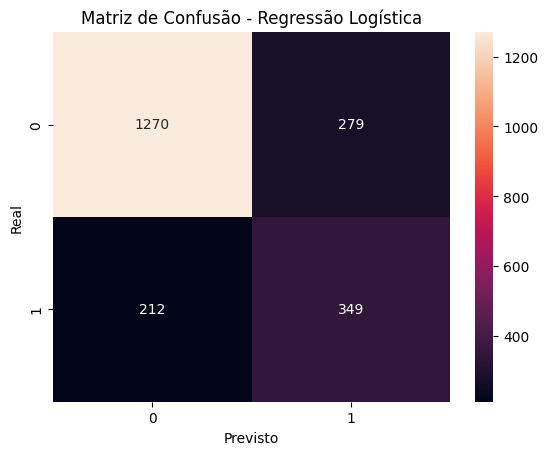

In [164]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d")

plt.title("Matriz de Confusão - Regressão Logística")
print('\n--- Matriz de Confusão ---')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# **17. Avaliação — Random Forest**

**17.1 - Random Forest**

In [165]:
print('\nRelatório de Classificação')
print("\nAcurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print('\nRelatório de Classificação')
print(classification_report(y_test, y_pred_rf))


Relatório de Classificação

Acurácia: 0.7682464454976303
Precisão: 0.5629370629370629
Recall: 0.5739750445632799
F1-score: 0.5684024713150927

Relatório de Classificação
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84      1549
         1.0       0.56      0.57      0.57       561

    accuracy                           0.77      2110
   macro avg       0.70      0.71      0.70      2110
weighted avg       0.77      0.77      0.77      2110



**17.2 - Matriz de Confusão**

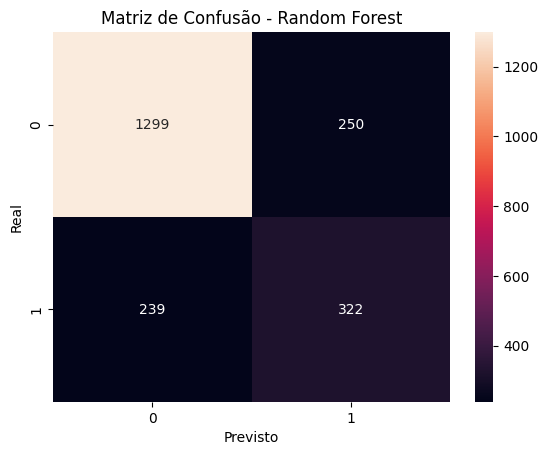

In [166]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# **18. Importância das Variáveis**

**18.1 - Random Forest**

In [167]:
importances = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(
    by="Importancia",
    ascending=False
)

importances.head(10)

,Variavel,Importancia
8,Charges.Total,0.143896
4,tenure,0.140101
9,Contas_Diarias,0.099678
7,Charges.Monthly,0.098969
29,PaymentMethod_Electronic check,0.089124
13,InternetService_Fiber optic,0.066753
27,Contract_Two year,0.033697
3,Dependents,0.031207
2,Partner,0.031043
0,gender,0.021793


**18.2 - Gráfico - Variáveis Mais Importantes**

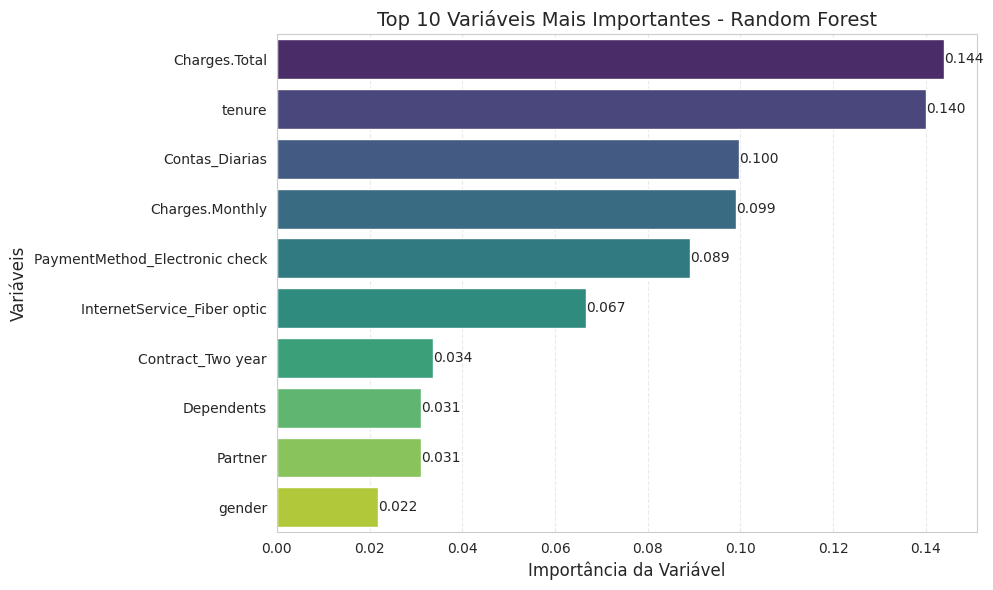

In [204]:
top_vars = importancia.sort_values(
    by="Importancia",
    ascending=False
).head(10)

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Importancia',
    y='Variavel',
    data=top_vars,
    hue='Variavel',
    palette='viridis',
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f')

plt.title('Top 10 Variáveis Mais Importantes - Random Forest', fontsize=14)
plt.xlabel('Importância da Variável', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# **19. Relatório completo**

**19.1 - Quais clientes têm MAIOR risco de evasão?**

In [169]:
taxa_churn = df['Churn'].value_counts(normalize=True) * 100
print(f"Taxa de Churn Geral: {taxa_churn[1.0]:.2f}%")
print(f"Taxa de Não Churn Geral: {taxa_churn[0.0]:.2f}%")

print(f"\nA taxa geral de evasão é de aproximadamente 27%,\nindicando que cerca de 1 em cada 4 clientes cancela o serviço.")

Taxa de Churn Geral: 26.54%
Taxa de Não Churn Geral: 73.46%

A taxa geral de evasão é de aproximadamente 27%,
indicando que cerca de 1 em cada 4 clientes cancela o serviço.


**19.2 - Churn por tipo de contrato**

In [170]:
print("\nConclusão!")
print(f"Clientes com contrato mensal têm o maior risco de evasão,\ncom taxas próximas de 40%.")
churn_contrato = pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100
churn_contrato


Conclusão!
Clientes com contrato mensal têm o maior risco de evasão,
com taxas próximas de 40%.


Churn,0.0,1.0
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**19.3 - Churn por tempo de cliente**

In [171]:
mean_tenure_by_churn = df.groupby('Churn')['tenure'].mean()
print("Tempo médio de contrato (em meses) por Churn:")
print(mean_tenure_by_churn)

print("Conclusão!")
print("Clientes que cancelam possuem tempo médio de contrato muito menor,\nindicando evasão principalmente nos primeiros meses.")

Tempo médio de contrato (em meses) por Churn:
Churn
0.0    37.569965
1.0    17.979133
Name: tenure, dtype: float64
Conclusão!
Clientes que cancelam possuem tempo médio de contrato muito menor,
indicando evasão principalmente nos primeiros meses.


**19.4 - Quais variáveis mais influenciam o churn?**

In [172]:
import pandas as pd

importances = rf_model.feature_importances_

features = X.columns

importancia = pd.DataFrame({
    'Variavel': features,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

importancia.head(10)

,Variavel,Importancia
8,Charges.Total,0.143896
4,tenure,0.140101
9,Contas_Diarias,0.099678
7,Charges.Monthly,0.098969
29,PaymentMethod_Electronic check,0.089124
13,InternetService_Fiber optic,0.066753
27,Contract_Two year,0.033697
3,Dependents,0.031207
2,Partner,0.031043
0,gender,0.021793


**19.5 - Correlação das Variáveis com Churn**

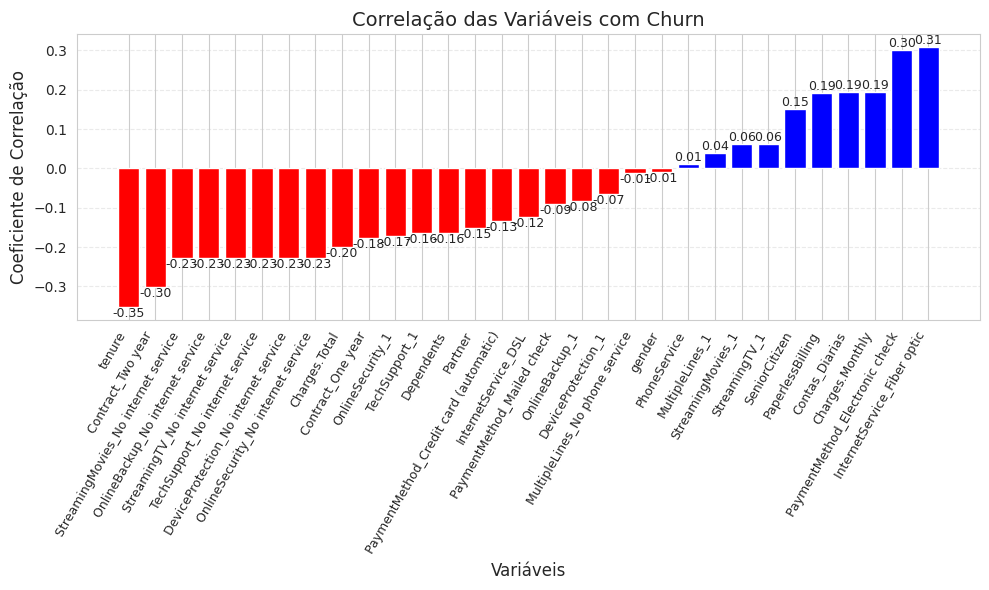

In [219]:
corr_data = corr_churn.drop('Churn')
corr_data = corr_data.sort_values()

cores = ['red' if x < 0 else 'blue' for x in corr_data]
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

bars = plt.bar(corr_data.index, corr_data.values, color=cores)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9
    )

plt.title('Correlação das Variáveis com Churn', fontsize=14)
plt.ylabel('Coeficiente de Correlação', fontsize=12)
plt.xlabel('Variáveis', fontsize=12)

plt.xticks(rotation=60, ha='right', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

**19.6 - Interpretação e Conclusões**

In [221]:
coef_df = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df['Impacto_Absoluto'] = coef_df['Coeficiente'].abs()
coef_df.sort_values(by='Impacto_Absoluto', ascending=False).head(10)


,Variavel,Coeficiente,Impacto_Absoluto
13,InternetService_Fiber optic,7.064326,7.064326
7,Charges.Monthly,-3.569575,3.569575
9,Contas_Diarias,-3.569575,3.569575
12,InternetService_DSL,3.286704,3.286704
4,tenure,-1.957423,1.957423
22,StreamingTV_1,1.320012,1.320012
24,StreamingMovies_1,1.298909,1.298909
8,Charges.Total,1.147375,1.147375
10,MultipleLines_1,0.772126,0.772126
29,PaymentMethod_Electronic check,0.680543,0.680543


# **20. Relatório descritivo do projeto**

**19.5 - Interpretação com dados numéricos do relatório**

A análise dos dados permitiu identificar os principais fatores que influenciam a evasão de clientes.

A taxa geral de evasão observada no conjunto de dados é de 26,58%, enquanto 73,42% dos clientes permanecem na empresa.


**Variáveis que mais influenciam a evasão**

**As análises indicam que as variáveis com maior impacto no comportamento de cancelamento são:**

1. Tipo de contrato (Contract)
2. Tempo de permanência do cliente (tenure)
3. Tipo de internet (InternetService)
4. Valor da mensalidade (Charges.Monthly)
5. Serviços adicionais de segurança e suporte


**Resultados numéricos encontrados**
**Tipo de contrato**

Taxa de evasão por contrato:

1. Tipo de contrato	Taxa de churn
2. Month-to-month	42,71%
3. One year	11,27%
4. Two year	2,85%

**Interpretação:**

Clientes com contrato mensal (Month-to-month) apresentam a maior taxa de evasão, com aproximadamente 42,7% de cancelamento.

Já clientes com contratos mais longos apresentam evasão muito menor.


**Tempo de permanência do cliente**

1. Situação	Tempo médio
2. Clientes que cancelaram	17,98 meses
3. Clientes que permaneceram	37,65 meses

**Interpretação:**

Clientes que cancelam permanecem menos da metade do tempo dos clientes que continuam na empresa.

Isso mostra que os primeiros meses do cliente são críticos para retenção.


**Tipo de serviço de internet**

**Taxa de churn por tipo de internet:**

1. Tipo de internet	Churn
2. Fiber optic	41,89%
3. DSL	18,99%
4. Sem internet	7,43%

**Interpretação:**

Clientes que utilizam fibra óptica apresentam maior taxa de evasão, com aproximadamente 41,9%.


**Valor da mensalidade**
**Média da mensalidade:**

**Situação	Valor médio**
1.  Clientes que permanecem	61,30
2. Clientes que cancelam	74,44

**Interpretação:**

Clientes que cancelam possuem mensalidade média mais alta, cerca de 13 reais acima dos clientes que permanecem.


**Perfil de cliente com maior risco de evasão**

Com base nas análises, o perfil com maior probabilidade de churn é:

1. Contrato Month-to-month

2. Tempo de empresa menor que 24 meses

3. Internet Fiber optic

4. Mensalidade mais alta

5. Ausência de serviços adicionais

6. Esse grupo apresenta taxas de evasão próximas ou superiores a 40%.


**Estratégias de retenção sugeridas**

Com base nos resultados obtidos, algumas estratégias podem ser adotadas para reduzir a evasão de clientes.

1. **Incentivar contratos de longo prazo**

Clientes com contratos de 1 ou 2 anos apresentam evasão inferior a 12%.

   **A empresa pode oferecer:**

1. Descontos
2. Benefícios adicionais
3. Bônus de fidelidade

Para incentivar a migração de contratos mensais.

2. **Programas de fidelização para novos clientes**

Clientes que cancelam permanecem em média 17,98 meses, indicando que os primeiros dois anos são críticos.

Programas de acompanhamento e benefícios iniciais podem ajudar a reduzir o churn.

3. **Oferecer serviços adicionais**

   **Serviços como:**

1. Segurança online

2. Backup

3. Suporte técnico

Podem aumentar o valor percebido pelo cliente e reduzir a probabilidade de cancelamento.

4. **Monitorar clientes com mensalidade elevada**

Clientes com churn pagam em média 74,44, enquanto os demais pagam 61,30.

   **A empresa pode oferecer:**

1. Planos mais flexíveis

2. Pacotes promocionais

3. Revisões de plano

4. Para reduzir o risco de cancelamento.

Agora, podemos analisar a taxa de churn por esses novos grupos de tempo de cliente.